# Centralized Machine Learning Unlearning Evaluation

## Unlearning Pipeline

### Pipeline:
1. **Train baseline model on ALL data** (full training set)
2. **Split data** into delete set (5%) and retain set (95%)
3. **Save split indices** for consistency across techniques
4. **Exact unlearning**: Retrain from scratch on retain set only
5. **Approximate unlearning**: Start from baseline → gradient ascent on delete set
6. **Compare**: How well did each method remove the influence of delete data?

### Evaluation Metrics:
- **Forgetting**: Delete set accuracy drop (Baseline → Unlearned)
- **Utility**: Retain set accuracy preservation
- **Privacy**: Membership Inference Attack (MIA)
- **Efficiency**: Time comparison vs exact retraining

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import pandas as pd
import time
import json
from datetime import datetime
import os
import sys

print("Libraries imported successfully")

Libraries imported successfully


In [11]:
# ============================================================================
# TRAINING HYPERPARAMETERS
# ============================================================================

SEED = 123
DELETE_RATIO = 0.10
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
TRAIN_EPOCHS = 15
LOSS_NAME = "CrossEntropyLoss"
DATASET_TAG = "CIFAR100"
NUM_CLASSES = 100  # CIFAR-100 has 100 classes

# Set all random seeds for reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device setup
device = torch.device("cpu")

print(f"\n{'=' * 70}")
print("EXPERIMENT CONFIGURATION")
print(f"{'=' * 70}")
print(f"Dataset:                 {DATASET_TAG}")
print(f"Seed:                    {SEED}")
print(f"Deletion ratio:          {DELETE_RATIO*100:.1f}%")
print(f"Batch size:              {BATCH_SIZE}")
print(f"Learning rate:           {LEARNING_RATE}")
print(f"Training epochs:         {TRAIN_EPOCHS}")
print(f"Loss:                    {LOSS_NAME}")
print(f"Device:                  {device}")
print(f"{'=' * 70}\n")


EXPERIMENT CONFIGURATION
Dataset:                 CIFAR100
Seed:                    123
Deletion ratio:          10.0%
Batch size:              64
Learning rate:           0.001
Training epochs:         15
Loss:                    CrossEntropyLoss
Device:                  cpu



In [12]:
# Plot saving setup (dataset + technique + seed + delete ratio)
TECHNIQUE_NAME = "gradient_ascent_and_gold"
seed_str = f"{SEED:04d}"
delete_ratio_str = f"{DELETE_RATIO:.4f}".rstrip("0").rstrip(".").replace(".", "p")
plot_output_dir = f"../results/plots/{DATASET_TAG}_{TECHNIQUE_NAME}_seed_{seed_str}_delete_{delete_ratio_str}"
os.makedirs(plot_output_dir, exist_ok=True)


def save_plot(fig, filename):
    filepath = os.path.join(plot_output_dir, filename)
    fig.savefig(filepath, dpi=300, bbox_inches="tight")
    print(f"Saved plot: {filepath}")


print(f"Plot directory ready: {plot_output_dir}")

Plot directory ready: ../results/plots/CIFAR100_gradient_ascent_and_gold_seed_0123_delete_0p1


In [13]:
# Standard preprocessing (official normalization)
transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.1307,), (0.3081,))       # MNIST official mean/std     # Normalizing 1 channel for MNIST dataset
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))         # Normalizing 3 channels instead of 1 for CIFAR-10 dataset
])

# Uncomment this block when using MNIST
# print("Loading MNIST dataset...")
# train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
# test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# CIFAR-100 loading
print(f"Loading {DATASET_TAG} dataset...")
train_dataset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

print(f"Full training data:      {len(train_dataset)}")
print(f"Holdout test data:       {len(test_dataset)}")
print(f"\nNote: Baseline model will be trained on ALL {len(train_dataset)} samples")

Loading CIFAR100 dataset...
Full training data:      50000
Holdout test data:       10000

Note: Baseline model will be trained on ALL 50000 samples


In [14]:
class SimpleCNN(nn.Module):
    """Simple CNN for classification."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # nn.Conv2d(1, 32, 3, 1),
            nn.Conv2d(3, 32, 3, 1), # Changed 1 to 3 for RGB
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            # nn.Linear(5408, 10),     # Original for MNIST with 28x28 input 
            # CIFAR-10 input 32x32 -> conv(3x3) gives 30x30 -> pool gives 15x15; 32*15*15 = 7200
            # nn.Linear(7200, 10), 
            nn.Linear(7200, 100), # Changed 10 to 100 for CIFAR-100 (100 classes instead of 10
        )

    def forward(self, x):
        return self.net(x)

In [15]:
def train(model, loader, epochs=1, device=torch.device("cpu"), verbose=True):
    """Train model on a dataloader."""
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()
    model.train()

    for epoch in range(1, epochs+1):
        running_loss = 0.0
        for batch_idx, (x, y) in enumerate(loader):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            if verbose and (batch_idx + 1) % 100 == 0:
                print(f"Epoch [{epoch}/{epochs}], Batch [{batch_idx+1}/{len(loader)}], Loss: {loss.item():.4f}")

        avg_epoch_loss = running_loss / len(loader)
        if verbose:
            print(f"--- Epoch {epoch} completed. Avg Loss: {avg_epoch_loss:.4f} ---")


def evaluate(model, loader, device=torch.device("cpu")):
    """Evaluate model accuracy and loss on a dataloader."""
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss_sum += criterion(outputs, y).item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct/total, loss_sum/len(loader)


def gradient_ascent_unlearning(model, delete_loader, lr=1e-4, steps=1, device=torch.device("cpu"), verbose=True):
    """Perform gradient-ascent unlearning on delete set."""
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.train()

    for step in range(1, steps+1):
        running_loss = 0.0
        for batch_idx, (x, y) in enumerate(delete_loader):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            (-loss).backward()  # gradient ASCENT (maximize loss on delete data)
            optimizer.step()
            running_loss += loss.item()

            if verbose and (batch_idx + 1) % 50 == 0:
                print(f"Step [{step}/{steps}], Batch [{batch_idx+1}/{len(delete_loader)}], Loss: {loss.item():.4f}")

        avg_loss = running_loss / len(delete_loader)
        if verbose:
            print(f"--- Step {step} completed. Avg Loss on deleted data: {avg_loss:.4f} ---")

In [16]:
# Import Membership Inference Attack (MIA) from separate module
sys.path.insert(0, '/Users/new/Desktop/unlearning')  # Add current notebook directory to path
from mia import evaluate_mia

## Stage 1: Train BASELINE Model on ALL Data

In [17]:
print("\n" + "="*70)
print("STAGE 1: BASELINE MODEL - Train on ALL data")
print("="*70)

# Create dataloader for FULL training set
full_train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

baseline_model = SimpleCNN().to(device)
print("\nModel architecture:")
print(baseline_model)


STAGE 1: BASELINE MODEL - Train on ALL data

Model architecture:
SimpleCNN(
  (net): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Flatten(start_dim=1, end_dim=-1)
    (4): Linear(in_features=7200, out_features=100, bias=True)
  )
)


In [18]:
print(f"\nTraining baseline model on ALL {len(train_dataset)} samples for {TRAIN_EPOCHS} epoch(s)...")
print("(Including data that will later be marked for deleting)\n")
start = time.time()
train(baseline_model, full_train_loader, epochs=TRAIN_EPOCHS, device=device)
baseline_train_time = time.time() - start
print(f"\nBaseline training completed in {baseline_train_time:.2f} seconds")


Training baseline model on ALL 50000 samples for 15 epoch(s)...
(Including data that will later be marked for deleting)

Epoch [1/15], Batch [100/782], Loss: 3.9001
Epoch [1/15], Batch [200/782], Loss: 3.6391
Epoch [1/15], Batch [300/782], Loss: 3.6975
Epoch [1/15], Batch [400/782], Loss: 3.2090
Epoch [1/15], Batch [500/782], Loss: 3.0017
Epoch [1/15], Batch [600/782], Loss: 3.1966
Epoch [1/15], Batch [700/782], Loss: 3.1998
--- Epoch 1 completed. Avg Loss: 3.3229 ---
Epoch [2/15], Batch [100/782], Loss: 2.8341
Epoch [2/15], Batch [200/782], Loss: 2.6938
Epoch [2/15], Batch [300/782], Loss: 2.2327
Epoch [2/15], Batch [400/782], Loss: 2.5548
Epoch [2/15], Batch [500/782], Loss: 2.8174
Epoch [2/15], Batch [600/782], Loss: 2.4425
Epoch [2/15], Batch [700/782], Loss: 2.5374
--- Epoch 2 completed. Avg Loss: 2.4889 ---
Epoch [3/15], Batch [100/782], Loss: 1.9577
Epoch [3/15], Batch [200/782], Loss: 2.1449
Epoch [3/15], Batch [300/782], Loss: 1.9217
Epoch [3/15], Batch [400/782], Loss: 1.977

## Stage 2: Split Data & Save Indices

In [19]:
print("\n" + "="*70)
print("STAGE 2: SPLIT DATA & SAVE INDICES")
print("="*70)

# Split training data: delete (to forget) and retain (to keep)
num_delete = int(DELETE_RATIO * len(train_dataset))
num_retain = len(train_dataset) - num_delete

indices = np.random.permutation(len(train_dataset))
delete_idx = sorted(indices[:num_delete])
retain_idx = sorted(indices[num_delete:])

retain_set = Subset(train_dataset, retain_idx)
delete_set = Subset(train_dataset, delete_idx)

print(f"\nData Split:")
print(f"  Retain set (keep):   {len(retain_set):6d} samples ({len(retain_set)/len(train_dataset)*100:5.1f}%)")
print(f"  Delete set (forget): {len(delete_set):6d} samples ({len(delete_set)/len(train_dataset)*100:5.1f}%)")
print(f"  Test set (holdout):  {len(test_dataset):6d} samples")

# Create dataloaders
retain_loader = DataLoader(retain_set, batch_size=BATCH_SIZE, shuffle=True)
delete_loader = DataLoader(delete_set, batch_size=BATCH_SIZE, shuffle=True)

# Save split indices for reuse across techniques
os.makedirs("../data_splits", exist_ok=True)
split_file = f"../data_splits/{DATASET_TAG}_split_seed_{SEED:04d}.npz"
np.savez(split_file, delete_idx=delete_idx, retain_idx=retain_idx)
print(f"\nSplit indices saved to: {split_file}")
print("(Can be reused for consistent evaluation across different unlearning techniques)")


STAGE 2: SPLIT DATA & SAVE INDICES

Data Split:
  Retain set (keep):    45000 samples ( 90.0%)
  Delete set (forget):   5000 samples ( 10.0%)
  Test set (holdout):   10000 samples

Split indices saved to: ../data_splits/CIFAR100_split_seed_0123.npz
(Can be reused for consistent evaluation across different unlearning techniques)


## Stage 3: Evaluate Baseline on All Sets

In [20]:
print("\n" + "="*70)
print("BASELINE PERFORMANCE (Before any unlearning)")
print("="*70)

# Evaluate baseline on all splits
retain_acc_before, retain_loss_before = evaluate(baseline_model, retain_loader, device)
delete_acc_before, delete_loss_before = evaluate(baseline_model, delete_loader, device)
test_acc_before, test_loss_before = evaluate(baseline_model, test_loader, device)

print(f"\nBaseline accuracy & loss:")
print(f"  Retain set:  Acc={retain_acc_before:.4f}, Loss={retain_loss_before:.4f}")
print(f"  Delete set:  Acc={delete_acc_before:.4f}, Loss={delete_loss_before:.4f}")
print(f"  Test set:    Acc={test_acc_before:.4f}, Loss={test_loss_before:.4f}")


BASELINE PERFORMANCE (Before any unlearning)

Baseline accuracy & loss:
  Retain set:  Acc=0.9364, Loss=0.2491
  Delete set:  Acc=0.9346, Loss=0.2546
  Test set:    Acc=0.3136, Loss=5.4074


## Stage 4A: Exact Unlearning - Retrain from Scratch

In [21]:
print("\n" + "="*70)
print("STAGE 4A: EXACT UNLEARNING - Retrain from scratch on RETAIN only")
print("="*70)

exact_model = SimpleCNN().to(device)
print(f"\nTraining exact model from scratch on ONLY retain set ({len(retain_set)} samples)...")
print("(This model NEVER sees delete data = ground truth unlearning)\n")

start = time.time()
train(exact_model, retain_loader, epochs=TRAIN_EPOCHS, device=device)
exact_time = time.time() - start
print(f"\nExact unlearning completed in {exact_time:.2f} seconds")


STAGE 4A: EXACT UNLEARNING - Retrain from scratch on RETAIN only

Training exact model from scratch on ONLY retain set (45000 samples)...
(This model NEVER sees delete data = ground truth unlearning)

Epoch [1/15], Batch [100/704], Loss: 3.4935
Epoch [1/15], Batch [200/704], Loss: 3.5900
Epoch [1/15], Batch [300/704], Loss: 3.1166
Epoch [1/15], Batch [400/704], Loss: 3.1277
Epoch [1/15], Batch [500/704], Loss: 3.1686
Epoch [1/15], Batch [600/704], Loss: 2.8363
Epoch [1/15], Batch [700/704], Loss: 2.8601
--- Epoch 1 completed. Avg Loss: 3.3755 ---
Epoch [2/15], Batch [100/704], Loss: 2.5891
Epoch [2/15], Batch [200/704], Loss: 2.5234
Epoch [2/15], Batch [300/704], Loss: 1.9171
Epoch [2/15], Batch [400/704], Loss: 2.3455
Epoch [2/15], Batch [500/704], Loss: 2.1864
Epoch [2/15], Batch [600/704], Loss: 2.1843
Epoch [2/15], Batch [700/704], Loss: 2.5636
--- Epoch 2 completed. Avg Loss: 2.5295 ---
Epoch [3/15], Batch [100/704], Loss: 2.2082
Epoch [3/15], Batch [200/704], Loss: 2.1394
Epoch 

In [22]:
# Evaluate exact model
exact_retain_acc, exact_retain_loss = evaluate(exact_model, retain_loader, device)
exact_delete_acc, exact_delete_loss = evaluate(exact_model, delete_loader, device)
exact_test_acc, exact_test_loss = evaluate(exact_model, test_loader, device)

print(f"\nExact model performance:")
print(f"  Retain set:  Acc={exact_retain_acc:.4f}, Loss={exact_retain_loss:.4f}")
print(f"  Delete set:  Acc={exact_delete_acc:.4f}, Loss={exact_delete_loss:.4f}  <- Should be LOW (forgotten)")
print(f"  Test set:    Acc={exact_test_acc:.4f}, Loss={exact_test_loss:.4f}")


Exact model performance:
  Retain set:  Acc=0.9515, Loss=0.2046
  Delete set:  Acc=0.3026, Loss=5.3296  <- Should be LOW (forgotten)
  Test set:    Acc=0.3118, Loss=5.3282


## Stage 4B: Approximate Unlearning - Gradient Ascent

In [23]:
print("\n" + "="*70)
print("STAGE 4B: APPROXIMATE UNLEARNING - Gradient ascent on delete set")
print("="*70)

approx_model = SimpleCNN().to(device)
approx_model.load_state_dict(baseline_model.state_dict())  # Start from baseline
print(f"\nStarting with baseline (trained on ALL data)")
print(f"Applying gradient ascent to MAXIMIZE loss on delete set...\n")

start_time = time.time()
gradient_ascent_unlearning(approx_model, delete_loader, lr=1e-4, steps=3, device=device)
approx_time = time.time() - start_time

print(f"\nApproximate unlearning completed in {approx_time:.2f} seconds")


STAGE 4B: APPROXIMATE UNLEARNING - Gradient ascent on delete set

Starting with baseline (trained on ALL data)
Applying gradient ascent to MAXIMIZE loss on delete set...

Step [1/3], Batch [50/79], Loss: 0.4412
--- Step 1 completed. Avg Loss on deleted data: 0.2696 ---
Step [2/3], Batch [50/79], Loss: 0.3621
--- Step 2 completed. Avg Loss on deleted data: 0.3392 ---
Step [3/3], Batch [50/79], Loss: 1.0978
--- Step 3 completed. Avg Loss on deleted data: 1.0157 ---

Approximate unlearning completed in 4.71 seconds


In [24]:
# Evaluate approximate model
approx_retain_acc, approx_retain_loss = evaluate(approx_model, retain_loader, device)
approx_delete_acc, approx_delete_loss = evaluate(approx_model, delete_loader, device)
approx_test_acc, approx_test_loss = evaluate(approx_model, test_loader, device)

print(f"\nApproximate model performance:")
print(f"  Retain set:  Acc={approx_retain_acc:.4f}, Loss={approx_retain_loss:.4f}  <- Should be HIGH (preserved)")
print(f"  Delete set:  Acc={approx_delete_acc:.4f}, Loss={approx_delete_loss:.4f}  <- Should be LOW (forgotten)")
print(f"  Test set:    Acc={approx_test_acc:.4f}, Loss={approx_test_loss:.4f}")


Approximate model performance:
  Retain set:  Acc=0.6024, Loss=2.3451  <- Should be HIGH (preserved)
  Delete set:  Acc=0.5978, Loss=2.4095  <- Should be LOW (forgotten)
  Test set:    Acc=0.2050, Loss=8.1006


## Stage 5: Comprehensive Evaluation

In [25]:
# Model distance
# def model_distance(model1, model2):
#     total = 0
#     for p1, p2 in zip(model1.parameters(), model2.parameters()):
#         total += torch.norm(p1 - p2).item()
#     return total

# distance_to_exact = model_distance(approx_model, exact_model)
def model_distance_metrics(approx_model, exact_model):
    sq_diff = 0.0
    sq_exact = 0.0
    
    for p_approx, p_exact in zip(approx_model.parameters(), exact_model.parameters()):
        # Sum of squared differences: ||theta_approx - theta_exact||^2
        sq_diff += torch.sum((p_approx - p_exact) ** 2)
        
        # Sum of squared magnitudes of the exact model: ||theta_exact||^2
        sq_exact += torch.sum(p_exact ** 2)
    
    abs_dist = torch.sqrt(sq_diff).item()
    norm_exact = torch.sqrt(sq_exact).item()
    
    # Relative distance: ||diff|| / ||exact||
    rel_dist = abs_dist / (norm_exact + 1e-12) # epsilon for stability
    
    return abs_dist, rel_dist

# Usage
abs_l2, rel_l2 = model_distance_metrics(approx_model, exact_model)

print(f"Absolute L2 Distance: {abs_l2:.4f}")
print(f"Relative Distance:    {rel_l2:.4%}") # Formats as a percentage

print("\n" + "="*70)
print("COMPREHENSIVE EVALUATION SUMMARY")
print("="*70)

summary_data = {
    "Metric": [
        "DELETE ACCURACY:",
        "  Baseline",
        "  Exact",
        "  Approx",
        "  Forgetting (Exact)",
        "  Forgetting (Approx)",
        "",
        "RETAIN ACCURACY:",
        "  Baseline",
        "  Exact",
        "  Approx",
        "  Utility Loss (Approx)",
        "",
        "TEST ACCURACY:",
        "  Baseline",
        "  Exact",
        "  Approx",
        "",
        "MODEL DISTANCE (UNLEARNING QUALITY):",
        "  Abs. L2 Distance ||W_app - W_ex||₂",
        "  Rel. L2 Distance (Error %)",
        "",
        "EFFICIENCY:",
        "  Exact time (seconds)",
        "  Approx time (seconds)",
        "  Speedup factor"
    ],
    "Value": [
        "",
        f"{delete_acc_before:.4f}",
        f"{exact_delete_acc:.4f}",
        f"{approx_delete_acc:.4f}",
        f"{delete_acc_before - exact_delete_acc:.4f}",
        f"{delete_acc_before - approx_delete_acc:.4f}",
        "",
        "",
        f"{retain_acc_before:.4f}",
        f"{exact_retain_acc:.4f}",
        f"{approx_retain_acc:.4f}",
        f"{retain_acc_before - approx_retain_acc:.4f}",
        "",
        "",
        f"{test_acc_before:.4f}",
        f"{exact_test_acc:.4f}",
        f"{approx_test_acc:.4f}",
        "",
        "",
        f"{abs_l2:.4f}",
        f"{rel_l2:.4%}",
        "",
        "",
        f"{exact_time:.2f}s",
        f"{approx_time:.2f}s",
        f"{exact_time/approx_time:.1f}x faster"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

Absolute L2 Distance: 140.5744
Relative Distance:    140.1112%

COMPREHENSIVE EVALUATION SUMMARY

                              Metric        Value
                    DELETE ACCURACY:             
                            Baseline       0.9346
                               Exact       0.3026
                              Approx       0.5978
                  Forgetting (Exact)       0.6320
                 Forgetting (Approx)       0.3368
                                                 
                    RETAIN ACCURACY:             
                            Baseline       0.9364
                               Exact       0.9515
                              Approx       0.6024
               Utility Loss (Approx)       0.3340
                                                 
                      TEST ACCURACY:             
                            Baseline       0.3136
                               Exact       0.3118
                              Approx       0.2050
  

## Stage 6: Privacy Evaluation - Membership Inference Attack

In [26]:
print("\n" + "="*70)
print("MEMBERSHIP INFERENCE ATTACK (MIA) - BASELINE MODEL")
print("="*70)
print("\nCan an attacker tell if data was in training set?")
print(f"Members:     retain_loader (in training)")
print(f"Non-members: delete_loader (in training)")
print("\nNote: Both are 'members' since baseline was trained on ALL data.")
print("      This shows the baseline's baseline vulnerability.\n")

mia_baseline = evaluate_mia(baseline_model, retain_loader, delete_loader, threshold=None)

print(f"MIA Accuracy:             {mia_baseline['mia_accuracy']:.4f}")
print(f"  (How well can attacker distinguish retain vs delete?)")
print(f"True Positive Rate (TPR): {mia_baseline['tpr']:.4f}")
print(f"False Positive Rate (FPR):{mia_baseline['fpr']:.4f}")


MEMBERSHIP INFERENCE ATTACK (MIA) - BASELINE MODEL

Can an attacker tell if data was in training set?
Members:     retain_loader (in training)
Non-members: delete_loader (in training)

Note: Both are 'members' since baseline was trained on ALL data.
      This shows the baseline's baseline vulnerability.

MIA Accuracy:             0.6671
  (How well can attacker distinguish retain vs delete?)
True Positive Rate (TPR): 0.7083
False Positive Rate (FPR):0.7034


In [27]:
print("\n" + "="*70)
print("MEMBERSHIP INFERENCE ATTACK (MIA) - AFTER UNLEARNING")
print("="*70)
print("\nCan attacker still distinguish retain vs delete samples?")
print("If unlearning works, delete samples should look 'unknown' to the model.\n")

mia_approx = evaluate_mia(approx_model, retain_loader, delete_loader, threshold=None)

print(f"MIA Accuracy:             {mia_approx['mia_accuracy']:.4f}")
print(f"True Positive Rate (TPR): {mia_approx['tpr']:.4f}")
print(f"False Positive Rate (FPR):{mia_approx['fpr']:.4f}")

privacy_gain = mia_baseline['mia_accuracy'] - mia_approx['mia_accuracy']
print(f"\nPrivacy Gain: {privacy_gain:+.4f}  (Positive = Better)")


MEMBERSHIP INFERENCE ATTACK (MIA) - AFTER UNLEARNING

Can attacker still distinguish retain vs delete samples?
If unlearning works, delete samples should look 'unknown' to the model.

MIA Accuracy:             0.5759
True Positive Rate (TPR): 0.5956
False Positive Rate (FPR):0.6010

Privacy Gain: +0.0912  (Positive = Better)


## Stage 6A: Per-Class Accuracy & Confusion Matrices

In [28]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def compute_confusion_matrix_and_per_class_metrics(model, loader, device=torch.device("cpu"), num_classes=None):
    """
    Compute confusion matrix and per-class accuracy metrics.

    Returns:
        cm: Confusion matrix (num_classes x num_classes)
        per_class_acc: Dictionary with per-class accuracy for each class
        y_true_all: All true labels
        y_pred_all: All predicted labels
    """
    if num_classes is None:
        num_classes = NUM_CLASSES

    model.eval()
    y_true_all = []
    y_pred_all = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, preds = torch.max(outputs, 1)
            y_true_all.extend(y.cpu().numpy())
            y_pred_all.extend(preds.cpu().numpy())

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)

    cm = confusion_matrix(y_true_all, y_pred_all, labels=range(num_classes))

    per_class_acc = {}
    for class_idx in range(num_classes):
        mask = (y_true_all == class_idx)
        if mask.sum() > 0:
            acc = (y_pred_all[mask] == class_idx).sum() / mask.sum()
            per_class_acc[class_idx] = acc
        else:
            per_class_acc[class_idx] = None

    return cm, per_class_acc, y_true_all, y_pred_all


def plot_confusion_matrix(cm, title, ax=None, cmap='Blues'):
    """Plot confusion matrix as heatmap."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 10))

    num_classes = cm.shape[0]
    
    # For large confusion matrices (>20 classes), disable annotations
    show_annot = num_classes <= 20
    tick_freq = 10 if num_classes > 20 else 1

    sns.heatmap(
        cm,
        annot=show_annot,
        fmt='d' if show_annot else '',
        cmap=cmap,
        ax=ax,
        xticklabels=tick_freq,
        yticklabels=tick_freq,
        cbar_kws={'label': 'Count'}
    )

    ax.set_xlabel('Predicted Label', fontweight='bold')
    ax.set_ylabel('True Label', fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')

    return ax

print("Confusion matrix and per-class metrics functions loaded")

Confusion matrix and per-class metrics functions loaded



BASELINE MODEL - Per-Class Accuracy & Confusion Matrix

Per-Class Accuracy on RETAIN set:
----------------------------------------
  Class 0: 0.9910
  Class 1: 0.9844
  Class 2: 0.9865
  Class 3: 0.9123
  Class 4: 0.9232
  Class 5: 0.9453
  Class 6: 0.9864
  Class 7: 0.8129
  Class 8: 0.9890
  Class 9: 0.9843
  Class 10: 0.8145
  Class 11: 0.7728
  Class 12: 0.8862
  Class 13: 0.9244
  Class 14: 0.9351
  Class 15: 0.9644
  Class 16: 0.9758
  Class 17: 0.9577
  Class 18: 0.7711
  Class 19: 0.9668
  Class 20: 0.9933
  Class 21: 0.9576
  Class 22: 0.9583
  Class 23: 0.9682
  Class 24: 0.9888
  Class 25: 0.8000
  Class 26: 0.9338
  Class 27: 0.9819
  Class 28: 0.9595
  Class 29: 0.9292
  Class 30: 0.9624
  Class 31: 0.9712
  Class 32: 0.7439
  Class 33: 0.9806
  Class 34: 0.9824
  Class 35: 0.9713
  Class 36: 0.9867
  Class 37: 0.8820
  Class 38: 0.9845
  Class 39: 0.9391
  Class 40: 0.9217
  Class 41: 0.9935
  Class 42: 0.9801
  Class 43: 0.9384
  Class 44: 0.9272
  Class 45: 0.9360
  Cl

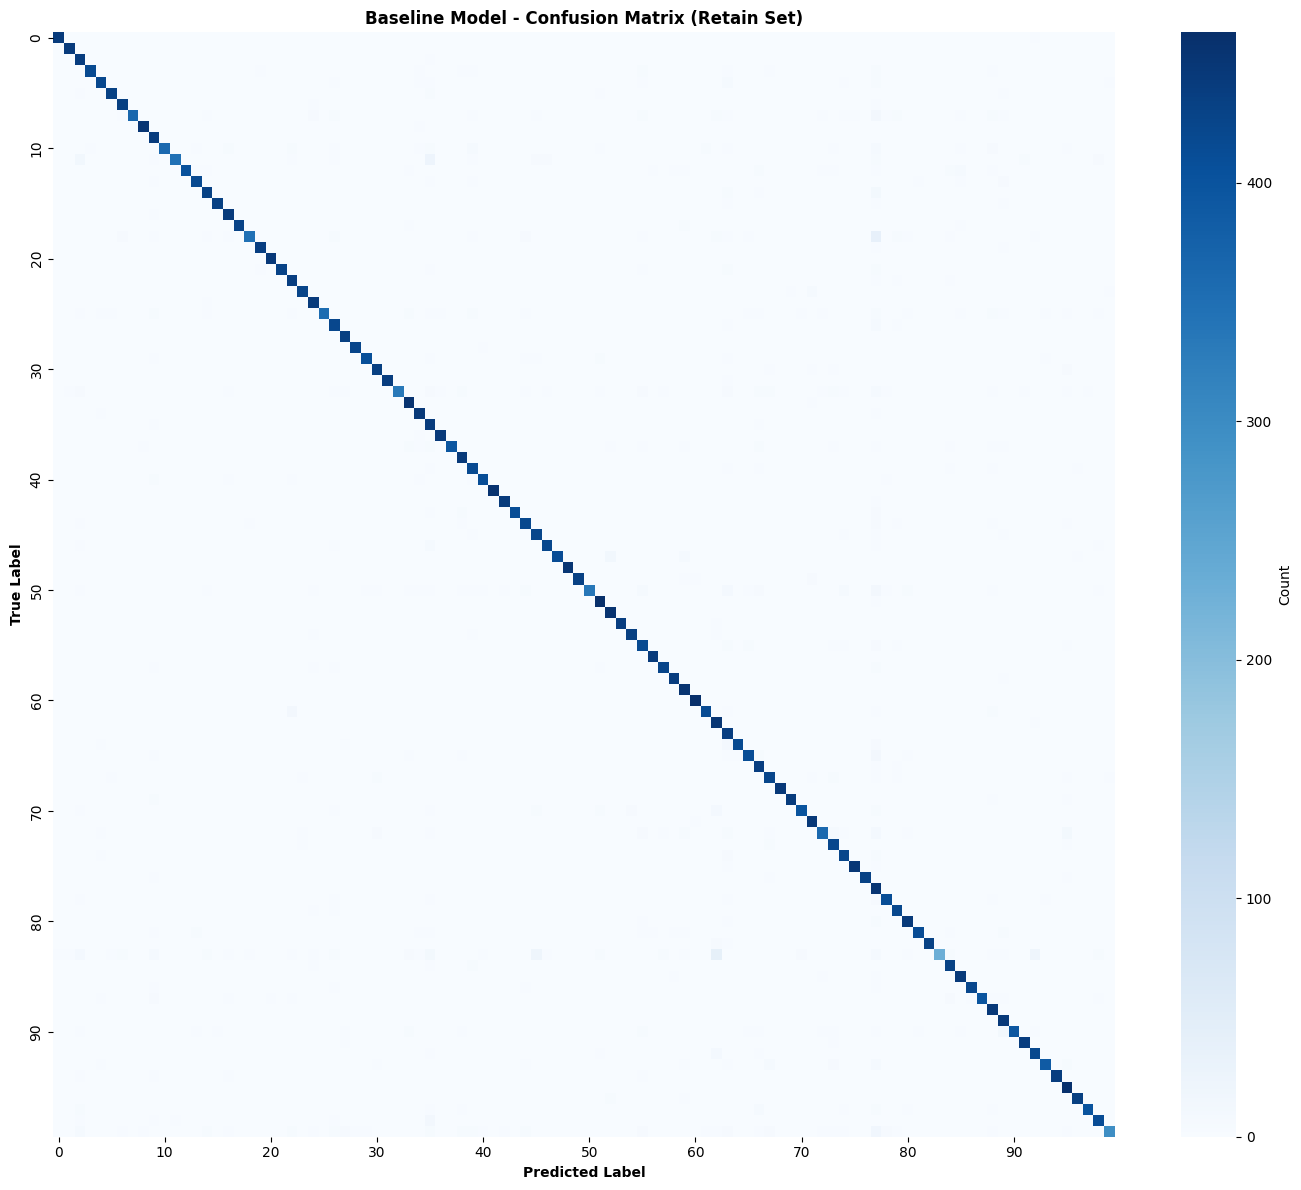

In [29]:
print("\n" + "="*70)
print("BASELINE MODEL - Per-Class Accuracy & Confusion Matrix")
print("="*70)

baseline_cm, baseline_per_class, _, _ = compute_confusion_matrix_and_per_class_metrics(
    baseline_model, retain_loader, device
)

# Display per-class accuracy
print("\nPer-Class Accuracy on RETAIN set:")
print("-" * 40)
for digit in range(100):
    acc = baseline_per_class[digit]
    if acc is not None:
        print(f"  Class {digit}: {acc:.4f}")

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(14, 12))
plot_confusion_matrix(baseline_cm, "Baseline Model - Confusion Matrix (Retain Set)", ax=ax)
plt.tight_layout()
save_plot(fig, "plot_01_baseline_confusion_matrix_retain.png")
plt.show()


EXACT UNLEARNING - Per-Class Accuracy & Confusion Matrix

Per-Class Accuracy on RETAIN set:
----------------------------------------
  Class 0: 0.9283
  Class 1: 0.9533
  Class 2: 0.9932
  Class 3: 0.9364
  Class 4: 0.9825
  Class 5: 0.9628
  Class 6: 0.9433
  Class 7: 0.9844
  Class 8: 1.0000
  Class 9: 0.9866
  Class 10: 0.9683
  Class 11: 0.9621
  Class 12: 0.9672
  Class 13: 0.9333
  Class 14: 0.8961
  Class 15: 0.9844
  Class 16: 0.9604
  Class 17: 0.9955
  Class 18: 0.9556
  Class 19: 0.8341
  Class 20: 0.9598
  Class 21: 0.9621
  Class 22: 0.9518
  Class 23: 0.9591
  Class 24: 0.9911
  Class 25: 0.9213
  Class 26: 0.9404
  Class 27: 0.9707
  Class 28: 0.9820
  Class 29: 0.9452
  Class 30: 0.9757
  Class 31: 0.9757
  Class 32: 0.8062
  Class 33: 0.9460
  Class 34: 0.9581
  Class 35: 0.9581
  Class 36: 0.8822
  Class 37: 0.9911
  Class 38: 0.9823
  Class 39: 0.9074
  Class 40: 0.9396
  Class 41: 0.9978
  Class 42: 0.9934
  Class 43: 0.9110
  Class 44: 0.9073
  Class 45: 0.9426
  

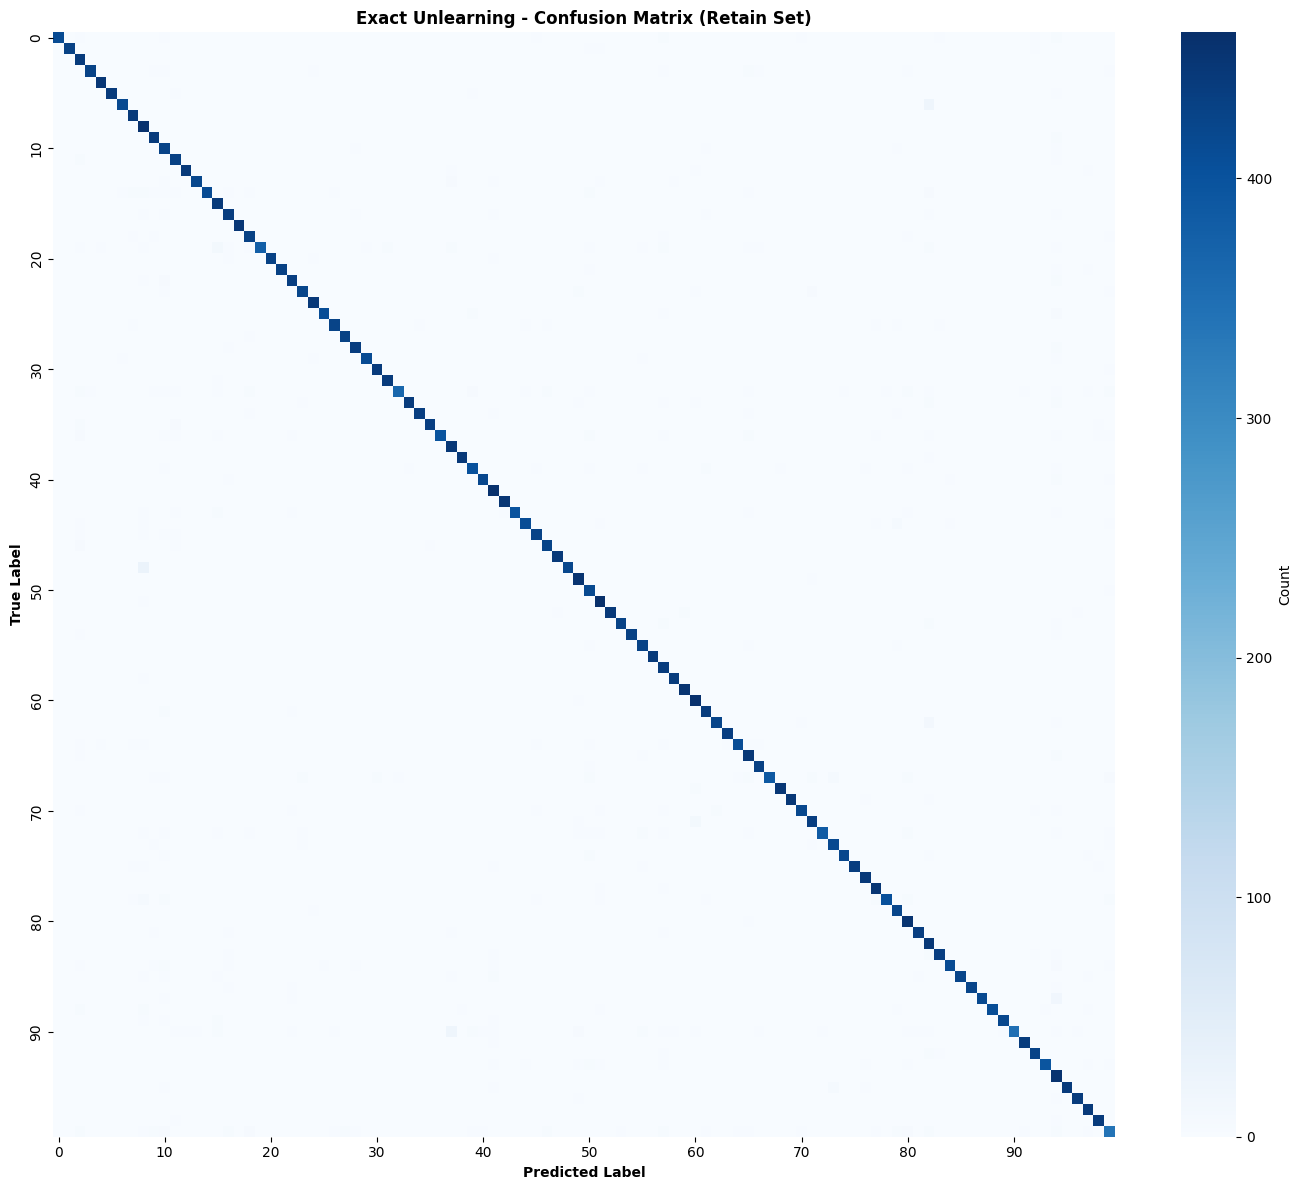

In [30]:
print("\n" + "="*70)
print("EXACT UNLEARNING - Per-Class Accuracy & Confusion Matrix")
print("="*70)

exact_cm, exact_per_class, _, _ = compute_confusion_matrix_and_per_class_metrics(
    exact_model, retain_loader, device
)

# Display per-class accuracy
print("\nPer-Class Accuracy on RETAIN set:")
print("-" * 40)
for digit in range(100):
    acc = exact_per_class[digit]
    if acc is not None:
        print(f"  Class {digit}: {acc:.4f}")

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(14, 12))
plot_confusion_matrix(exact_cm, "Exact Unlearning - Confusion Matrix (Retain Set)", ax=ax)
plt.tight_layout()
save_plot(fig, "plot_02_exact_confusion_matrix_retain.png")
plt.show()


GRADIENT ASCENT UNLEARNING - Per-Class Accuracy & Confusion Matrix

Per-Class Accuracy on RETAIN set:
----------------------------------------
  Class 0: 0.8543
  Class 1: 0.7067
  Class 2: 0.7275
  Class 3: 0.3443
  Class 4: 0.8794
  Class 5: 0.8359
  Class 6: 0.5578
  Class 7: 0.2806
  Class 8: 0.7149
  Class 9: 0.7875
  Class 10: 0.4683
  Class 11: 0.3853
  Class 12: 0.2276
  Class 13: 0.2400
  Class 14: 0.6277
  Class 15: 0.6748
  Class 16: 0.6828
  Class 17: 0.5367
  Class 18: 0.3422
  Class 19: 0.7080
  Class 20: 0.9397
  Class 21: 0.1205
  Class 22: 0.6535
  Class 23: 0.8432
  Class 24: 0.8367
  Class 25: 0.6090
  Class 26: 0.6733
  Class 27: 0.8781
  Class 28: 0.5248
  Class 29: 0.6142
  Class 30: 0.5088
  Class 31: 0.5774
  Class 32: 0.5590
  Class 33: 0.5227
  Class 34: 0.6982
  Class 35: 0.6777
  Class 36: 0.6689
  Class 37: 0.2383
  Class 38: 0.9490
  Class 39: 0.6366
  Class 40: 0.6018
  Class 41: 0.6885
  Class 42: 0.7080
  Class 43: 0.4612
  Class 44: 0.8190
  Class 45:

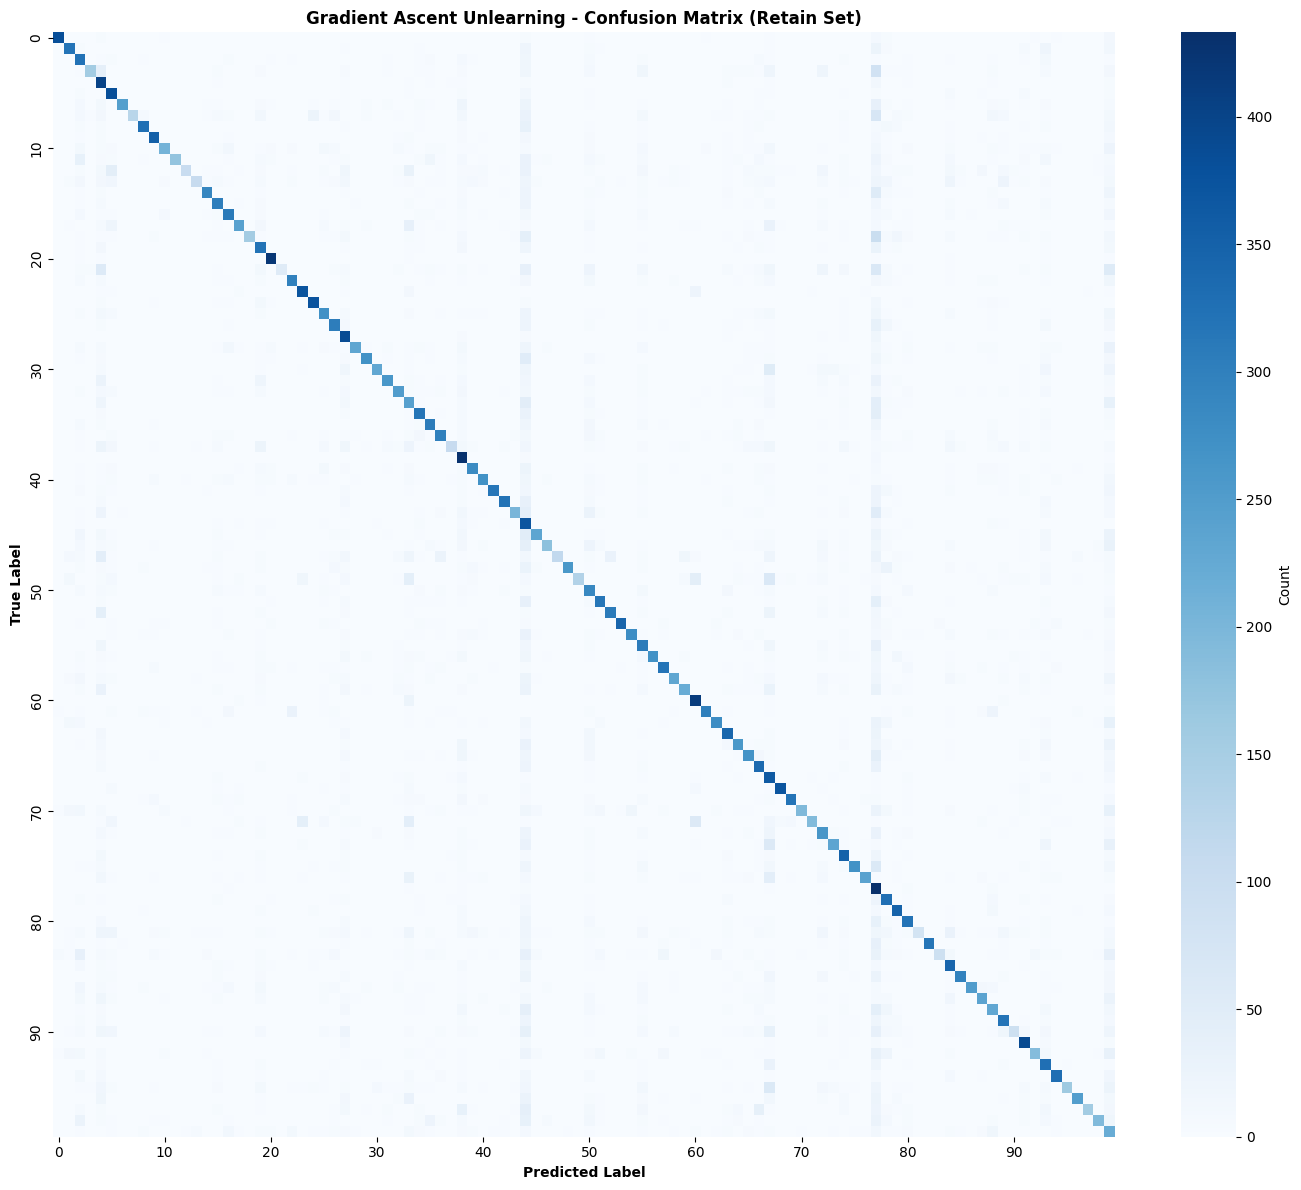

In [31]:
print("\n" + "="*70)
print("GRADIENT ASCENT UNLEARNING - Per-Class Accuracy & Confusion Matrix")
print("="*70)

approx_cm, approx_per_class, _, _ = compute_confusion_matrix_and_per_class_metrics(
    approx_model, retain_loader, device
)

# Display per-class accuracy
print("\nPer-Class Accuracy on RETAIN set:")
print("-" * 40)
for digit in range(100):
    acc = approx_per_class[digit]
    if acc is not None:
        print(f"  Class {digit}: {acc:.4f}")

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(14, 12))
plot_confusion_matrix(approx_cm, "Gradient Ascent Unlearning - Confusion Matrix (Retain Set)", ax=ax)
plt.tight_layout()
save_plot(fig, "plot_03_gradient_ascent_confusion_matrix_retain.png")
plt.show()

In [32]:
print("\n" + "="*70)
print("PER-CLASS ACCURACY COMPARISON (RETAIN SET)")
print("="*70)

def safe_subtract(a, b):
    if a is None or b is None:
        return np.nan
    return a - b

# Create comparison dataframe
comparison_data = {
    'Class': list(range(NUM_CLASSES)),
    'Baseline': [baseline_per_class[d] if baseline_per_class[d] is not None else np.nan for d in range(NUM_CLASSES)],
    'Exact (Retrained)': [exact_per_class[d] if exact_per_class[d] is not None else np.nan for d in range(NUM_CLASSES)],
    'Approx (Grad Ascent)': [approx_per_class[d] if approx_per_class[d] is not None else np.nan for d in range(NUM_CLASSES)],
}

# Add utility loss (drop from baseline to approx)
comparison_data['Utility Loss (Approx)'] = [
    safe_subtract(baseline_per_class[d], approx_per_class[d]) for d in range(NUM_CLASSES)
]

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# Summary statistics
print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"\nAverage per-class accuracy (RETAIN set):")
print(f"  Baseline:              {comparison_df['Baseline'].mean():.4f}")
print(f"  Exact (Retrained):     {comparison_df['Exact (Retrained)'].mean():.4f}")
print(f"  Approx (Grad Ascent):  {comparison_df['Approx (Grad Ascent)'].mean():.4f}")
print(f"\nAverage utility loss:    {comparison_df['Utility Loss (Approx)'].mean():.4f}")
print(f"Max utility loss (most affected class): Class {comparison_df['Utility Loss (Approx)'].idxmax()} ({comparison_df['Utility Loss (Approx)'].max():.4f})")
print(f"Min utility loss (least affected class): Class {comparison_df['Utility Loss (Approx)'].idxmin()} ({comparison_df['Utility Loss (Approx)'].min():.4f})")


PER-CLASS ACCURACY COMPARISON (RETAIN SET)

 Class  Baseline  Exact (Retrained)  Approx (Grad Ascent)  Utility Loss (Approx)
     0  0.991031           0.928251              0.854260               0.136771
     1  0.984444           0.953333              0.706667               0.277778
     2  0.986486           0.993243              0.727477               0.259009
     3  0.912281           0.936404              0.344298               0.567982
     4  0.923246           0.982456              0.879386               0.043860
     5  0.945295           0.962801              0.835886               0.109409
     6  0.986395           0.943311              0.557823               0.428571
     7  0.812918           0.984410              0.280624               0.532294
     8  0.989035           1.000000              0.714912               0.274123
     9  0.984340           0.986577              0.787472               0.196868
    10  0.814480           0.968326              0.468326       

In [33]:
print("\n" + "="*70)
print("DELETE SET PERFORMANCE - Per-Class Accuracy")
print("="*70)
print("\nForgetting Score: How much baseline accuracy decreased per class")
print("(Higher = better forgetting)")

def safe_subtract(a, b):
    if a is None or b is None:
        return np.nan
    return a - b

# Compute per-class metrics on DELETE set
baseline_delete_cm, baseline_delete_pc, _, _ = compute_confusion_matrix_and_per_class_metrics(
    baseline_model, delete_loader, device
)
exact_delete_cm, exact_delete_pc, _, _ = compute_confusion_matrix_and_per_class_metrics(
    exact_model, delete_loader, device
)
approx_delete_cm, approx_delete_pc, _, _ = compute_confusion_matrix_and_per_class_metrics(
    approx_model, delete_loader, device
)

# Create comparison dataframe for DELETE set
delete_comparison_data = {
    'Class': list(range(NUM_CLASSES)),
    'Baseline (Before)': [baseline_delete_pc[d] if baseline_delete_pc[d] is not None else np.nan for d in range(NUM_CLASSES)],
    'Exact (After)': [exact_delete_pc[d] if exact_delete_pc[d] is not None else np.nan for d in range(NUM_CLASSES)],
    'Approx (After)': [approx_delete_pc[d] if approx_delete_pc[d] is not None else np.nan for d in range(NUM_CLASSES)],
}

# Forgetting scores
delete_comparison_data['Forgetting (Exact)'] = [
    safe_subtract(baseline_delete_pc[d], exact_delete_pc[d]) for d in range(NUM_CLASSES)
]
delete_comparison_data['Forgetting (Approx)'] = [
    safe_subtract(baseline_delete_pc[d], approx_delete_pc[d]) for d in range(NUM_CLASSES)
]

delete_comparison_df = pd.DataFrame(delete_comparison_data)
print("\n" + delete_comparison_df.to_string(index=False))

print("\n" + "="*70)
print("DELETE SET SUMMARY")
print("="*70)
print(f"\nAverage per-class accuracy on DELETE set:")
print(f"  Baseline (Before):     {delete_comparison_df['Baseline (Before)'].mean():.4f}")
print(f"  Exact (After):         {delete_comparison_df['Exact (After)'].mean():.4f}")
print(f"  Approx (After):        {delete_comparison_df['Approx (After)'].mean():.4f}")

print(f"\nAverage Forgetting Score:")
print(f"  Exact Method:          {delete_comparison_df['Forgetting (Exact)'].mean():.4f}")
print(f"  Approx Method:         {delete_comparison_df['Forgetting (Approx)'].mean():.4f}")

valid_forgetting = delete_comparison_df['Forgetting (Approx)'].dropna()
if len(valid_forgetting) > 0:
    best_class = int(valid_forgetting.idxmax())
    worst_class = int(valid_forgetting.idxmin())
    print(f"\nBest Forgetting (Approx): Class {best_class} ({valid_forgetting.max():.4f})")
    print(f"Worst Forgetting (Approx): Class {worst_class} ({valid_forgetting.min():.4f})")
else:
    print("\nNo valid per-class forgetting scores available on DELETE set.")


DELETE SET PERFORMANCE - Per-Class Accuracy

Forgetting Score: How much baseline accuracy decreased per class
(Higher = better forgetting)

 Class  Baseline (Before)  Exact (After)  Approx (After)  Forgetting (Exact)  Forgetting (Approx)
     0           0.944444       0.500000        0.759259            0.444444             0.185185
     1           0.980000       0.320000        0.680000            0.660000             0.300000
     2           0.982143       0.285714        0.785714            0.696429             0.196429
     3           0.954545       0.113636        0.272727            0.840909             0.681818
     4           0.909091       0.090909        0.818182            0.818182             0.090909
     5           0.953488       0.279070        0.930233            0.674419             0.023256
     6           0.966102       0.254237        0.508475            0.711864             0.457627
     7           0.745098       0.235294        0.352941            0.50980


CONFUSION MATRIX COMPARISON - All Three Techniques
Saved plot: ../results/plots/CIFAR100_gradient_ascent_and_gold_seed_0123_delete_0p1/plot_04_confusion_matrix_comparison_retain.png


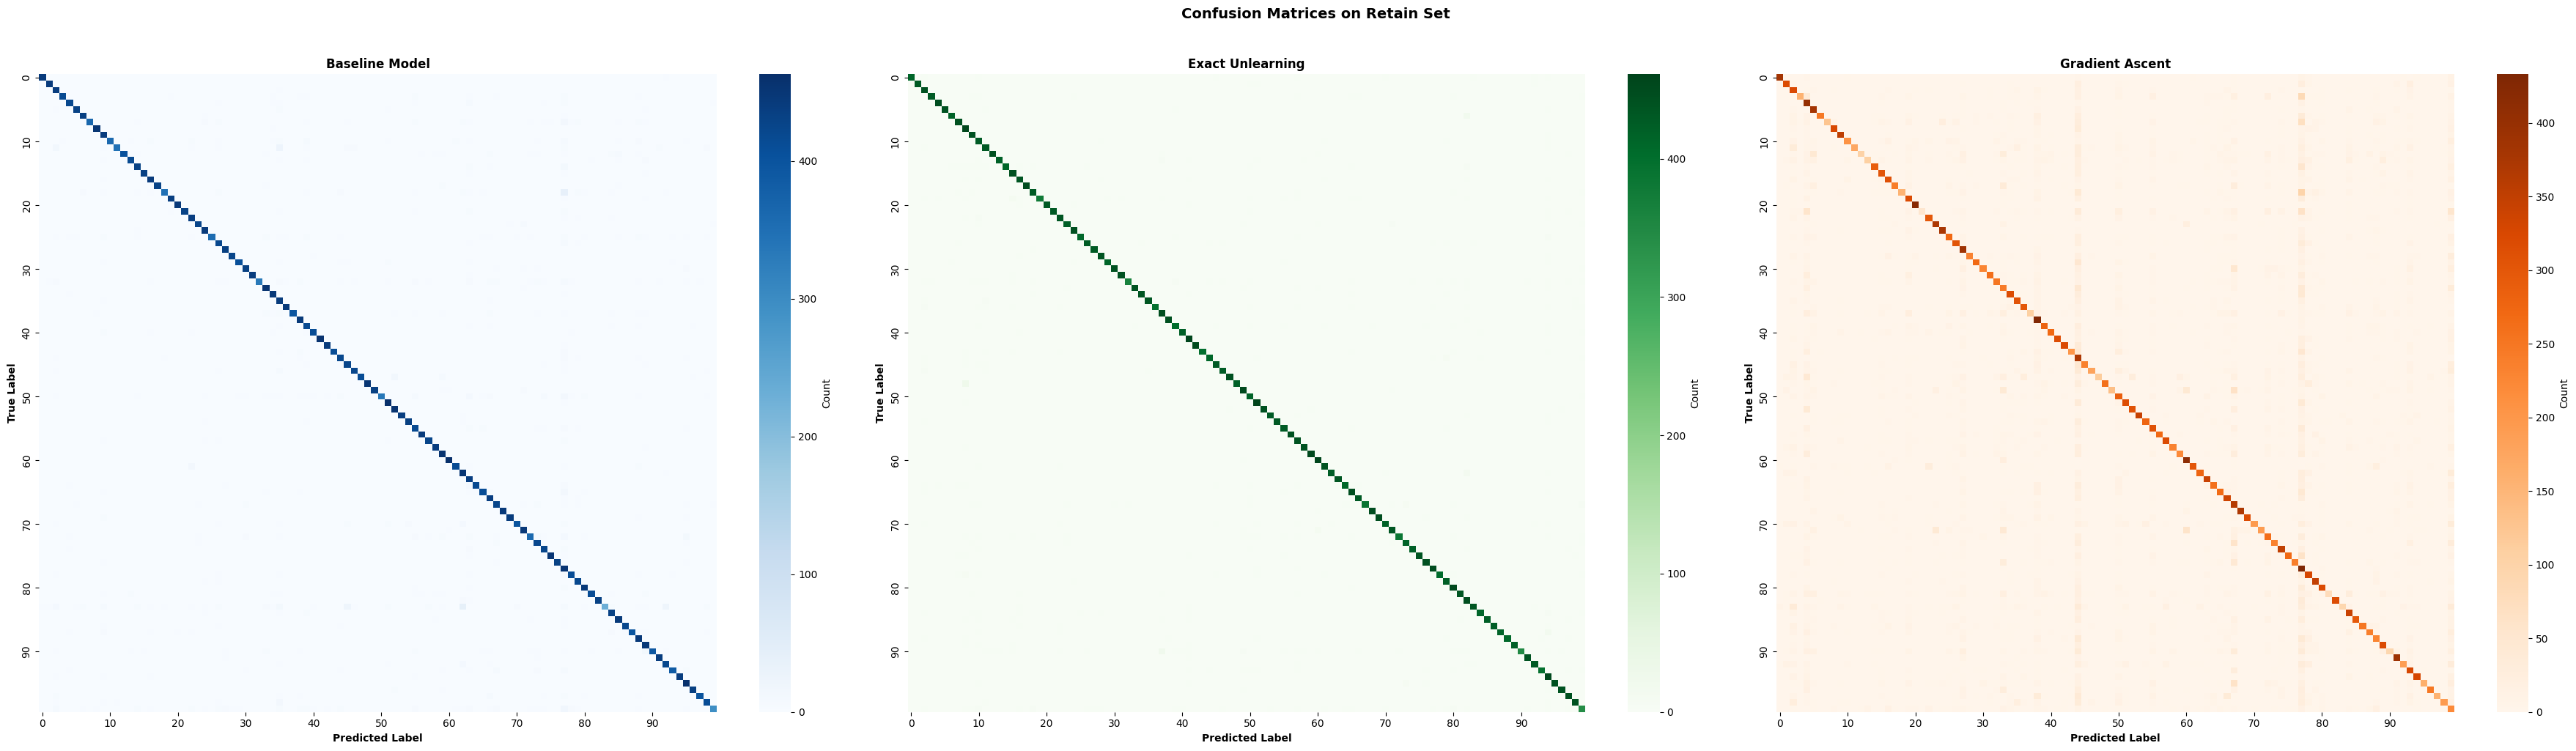

Confusion matrices visualized


In [34]:
print("\n" + "="*70)
print("CONFUSION MATRIX COMPARISON - All Three Techniques")
print("="*70)

# Create side-by-side confusion matrices (RETAIN set)
fig, axes = plt.subplots(1, 3, figsize=(36, 10))

plot_confusion_matrix(baseline_cm, "Baseline Model", ax=axes[0], cmap='Blues')
plot_confusion_matrix(exact_cm, "Exact Unlearning", ax=axes[1], cmap='Greens')
plot_confusion_matrix(approx_cm, "Gradient Ascent", ax=axes[2], cmap='Oranges')

plt.suptitle('Confusion Matrices on Retain Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot(fig, "plot_04_confusion_matrix_comparison_retain.png")
plt.show()

print("Confusion matrices visualized")


PER-CLASS ACCURACY VISUALIZATION (RETAIN SET)
Saved plot: ../results/plots/CIFAR100_gradient_ascent_and_gold_seed_0123_delete_0p1/plot_05_per_class_accuracy_and_utility_loss.png


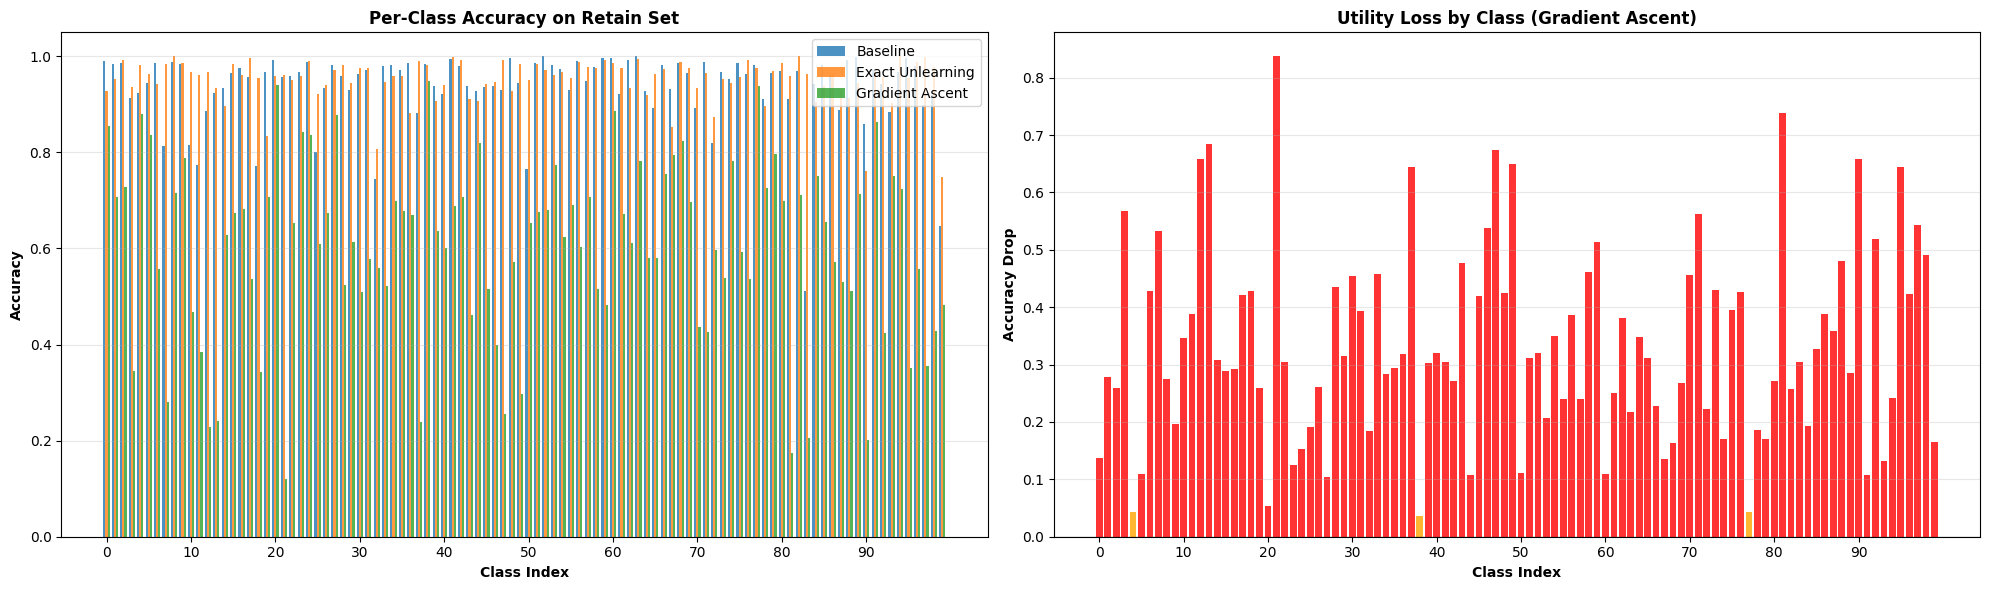

Per-class accuracy visualization complete


In [35]:
print("\nPER-CLASS ACCURACY VISUALIZATION (RETAIN SET)")

# Create bar chart comparing per-class accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot 1: Per-class accuracy for all three methods
classes = list(range(100))
x = np.arange(len(classes))
width = 0.25

baseline_accs = [baseline_per_class[d] for d in range(100)]
exact_accs = [exact_per_class[d] for d in range(100)]
approx_accs = [approx_per_class[d] for d in range(100)]

ax1.bar(x - width, baseline_accs, width, label='Baseline', alpha=0.8)
ax1.bar(x, exact_accs, width, label='Exact Unlearning', alpha=0.8)
ax1.bar(x + width, approx_accs, width, label='Gradient Ascent', alpha=0.8)

ax1.set_xlabel('Class Index', fontweight='bold')
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.set_title('Per-Class Accuracy on Retain Set', fontweight='bold')
# Show every 10th class label for readability
ax1.set_xticks(x[::10])
ax1.set_xticklabels(classes[::10])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1.05])

# Plot 2: Utility Loss (how much each class dropped with gradient ascent)
utility_losses = [baseline_per_class[d] - approx_per_class[d] for d in range(100)]
colors = ['red' if loss > 0.05 else 'orange' if loss > 0.02 else 'green' for loss in utility_losses]
ax2.bar(classes, utility_losses, color=colors, alpha=0.8)

ax2.set_xlabel('Class Index', fontweight='bold')
ax2.set_ylabel('Accuracy Drop', fontweight='bold')
ax2.set_title('Utility Loss by Class (Gradient Ascent)', fontweight='bold')
# Show every 10th class label for readability
ax2.set_xticks(classes[::10])
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
save_plot(fig, "plot_05_per_class_accuracy_and_utility_loss.png")
plt.show()

print("Per-class accuracy visualization complete")

## Stage 7: Save Results

In [36]:
def to_float_or_none(value):
    return float(value) if value is not None else None


def diff_or_none(a, b):
    if a is None or b is None:
        return None
    return float(a - b)


results = {
    "experiment_info": {
        "timestamp": datetime.now().isoformat(),
        "seed": SEED,
        "dataset": DATASET_TAG,
        "model": "SimpleCNN",
        "deletion_ratio": DELETE_RATIO,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "epochs": TRAIN_EPOCHS,
        "loss": LOSS_NAME,
        "device": str(device),
        "important_note": "Baseline trained on ALL data, then split for evaluation"
    },

    "baseline_model": {
        "train_time_seconds": baseline_train_time,
        "trained_on": f"All {len(train_dataset)} training samples",
        "delete_set_accuracy": float(delete_acc_before),
        "delete_set_loss": float(delete_loss_before),
        "retain_set_accuracy": float(retain_acc_before),
        "test_accuracy": float(test_acc_before),
        "per_class_accuracy": {
            "retain_set": {str(class_idx): to_float_or_none(baseline_per_class[class_idx]) for class_idx in range(NUM_CLASSES)},
            "delete_set": {str(class_idx): to_float_or_none(baseline_delete_pc[class_idx]) for class_idx in range(NUM_CLASSES)},
        },
    },

    "exact_unlearning": {
        "method": "Retrain from scratch on retain set only",
        "train_time_seconds": exact_time,
        "delete_set_accuracy": float(exact_delete_acc),
        "delete_set_loss": float(exact_delete_loss),
        "forgetting_score": float(delete_acc_before - exact_delete_acc),
        "retain_set_accuracy": float(exact_retain_acc),
        "test_accuracy": float(exact_test_acc),
        "per_class_accuracy": {
            "retain_set": {str(class_idx): to_float_or_none(exact_per_class[class_idx]) for class_idx in range(NUM_CLASSES)},
            "delete_set": {str(class_idx): to_float_or_none(exact_delete_pc[class_idx]) for class_idx in range(NUM_CLASSES)},
        },
        "per_class_forgetting_score": {
            str(class_idx): diff_or_none(baseline_delete_pc[class_idx], exact_delete_pc[class_idx]) for class_idx in range(NUM_CLASSES)
        },
    },

    "approx_unlearning": {
        "method": "Gradient ascent on delete set",
        "hyperparameters": {
            "lr": 1e-4,
            "steps": 3,
            "optimizer": "SGD"
        },
        "train_time_seconds": approx_time,
        "delete_set_accuracy": float(approx_delete_acc),
        "delete_set_loss": float(approx_delete_loss),
        "forgetting_score": float(delete_acc_before - approx_delete_acc),
        "retain_set_accuracy": float(approx_retain_acc),
        "utility_loss": float(retain_acc_before - approx_retain_acc),
        "test_accuracy": float(approx_test_acc),
        "per_class_accuracy": {
            "retain_set": {str(class_idx): to_float_or_none(approx_per_class[class_idx]) for class_idx in range(NUM_CLASSES)},
            "delete_set": {str(class_idx): to_float_or_none(approx_delete_pc[class_idx]) for class_idx in range(NUM_CLASSES)},
        },
        "per_class_forgetting_score": {
            str(class_idx): diff_or_none(baseline_delete_pc[class_idx], approx_delete_pc[class_idx]) for class_idx in range(NUM_CLASSES)
        },
        "per_class_utility_loss": {
            str(class_idx): diff_or_none(baseline_per_class[class_idx], approx_per_class[class_idx]) for class_idx in range(NUM_CLASSES)
        },
        "distance_metrics": {
            "l2_absolute": float(abs_l2),
            "l2_relative": float(rel_l2),
            "metric_definition": "Global L2 norm over all parameters"
        },
    },

    "efficiency_comparison": {
        "exact_time_seconds": exact_time,
        "approx_time_seconds": approx_time,
        "speedup_factor": float(exact_time / approx_time) if approx_time > 0 else None,
    },

    "privacy_evaluation_mia": {
        "baseline_model": {
            "mia_accuracy": mia_baseline['mia_accuracy'],
            "tpr": mia_baseline['tpr'],
            "fpr": mia_baseline['fpr'],
        },
        "after_unlearning": {
            "mia_accuracy": mia_approx['mia_accuracy'],
            "tpr": mia_approx['tpr'],
            "fpr": mia_approx['fpr'],
        },
        "privacy_gain": float(privacy_gain),
    },

    "data_split_info": {
        "total_training_samples": len(train_dataset),
        "delete_set_size": len(delete_set),
        "retain_set_size": len(retain_set),
        "test_set_size": len(test_dataset),
        "split_saved_to": split_file,
    }
}

# Create output directories
os.makedirs("../results", exist_ok=True)
os.makedirs("../results/metadata", exist_ok=True)
os.makedirs("../models", exist_ok=True)

# Save model checkpoints
baseline_model_path = f"../models/{DATASET_TAG}_baseline_seed_{SEED:04d}.pt"
gold_model_path = f"../models/{DATASET_TAG}_gold_exact_seed_{SEED:04d}.pt"
approx_model_path = f"../models/{DATASET_TAG}_approx_unlearned_seed_{SEED:04d}.pt"

torch.save(baseline_model.state_dict(), baseline_model_path)
torch.save(exact_model.state_dict(), gold_model_path)
torch.save(approx_model.state_dict(), approx_model_path)

# Add checkpoint paths to results
results["saved_models"] = {
    "baseline_model_path": baseline_model_path,
    "gold_model_path": gold_model_path,
    "approx_model_path": approx_model_path
}

# Save metrics JSON
filename = f"../results/metadata/{DATASET_TAG}_unlearning_seed_{SEED:04d}_{DELETE_RATIO}_results.json"
with open(filename, "w") as f:
    json.dump(results, f, indent=4)

print(f"\n Results saved to: {filename}")
print(f" Data split saved to: {split_file}")
print(f" Baseline model saved to: {baseline_model_path}")
print(f" Gold (exact retrained) model saved to: {gold_model_path}")
print(f" Approx unlearned model saved to: {approx_model_path}")


 Results saved to: ../results/metadata/CIFAR100_unlearning_seed_0123_0.1_results.json
 Data split saved to: ../data_splits/CIFAR100_split_seed_0123.npz
 Baseline model saved to: ../models/CIFAR100_baseline_seed_0123.pt
 Gold (exact retrained) model saved to: ../models/CIFAR100_gold_exact_seed_0123.pt
 Approx unlearned model saved to: ../models/CIFAR100_approx_unlearned_seed_0123.pt
